In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import LeaveOneOut,KFold
from sklearn.metrics import mean_squared_error,mean_absolute_error,mean_absolute_percentage_error,r2_score
from itertools import product

In [ ]:
data = pd.read_excel('Microwave_Pyrolysis_Dataset.xlsx')
#we need to specify the dirction where to see thesse names
data = data.drop(columns=['No.','Ref','Catalyst','Biomass'])

In [ ]:
X= data.drop(['Gas yield','Oil yield','Char yield'], axis = 1, inplace= False)
y = data['Gas yield']
# y_oil = data['Oil yield']
# y_char = data['Char yield']

In [ ]:
para = {
    'max_depth': [8,10,22],
    'min_samples_split': [8,2],
    'min_samples_leaf': [2,1]
}

para_comb = list(product(para['max_depth'],para['min_samples_split'],para['min_samples_leaf']))



In [ ]:
mse_hist =[]
mse = 0
best_para = None
bmse = float('inf')

for max_depth,min_samples_split,min_samples_leaf in para_comb:
    model = DecisionTreeRegressor(max_depth = max_depth,min_samples_split = min_samples_split,min_samples_leaf= min_samples_leaf,random_state =42)

    loo = LeaveOneOut()

    mse_hist =[]
    mse_tr_hist=[]
    for train_idx,test_idx in loo.split(X):
      x_train,y_train,x_test,y_test= X.iloc[train_idx],y.iloc[train_idx],X.iloc[test_idx],y.iloc[test_idx]
      #we ned to take only the int not the words
      model.fit(x_train,y_train)

      y_pred = model.predict(x_test)
      y_pred_tr = model.predict(x_train)
      mse_hist.append(mean_squared_error(y_pred,y_test))
      mse_tr_hist.append(mean_squared_error(y_pred_tr,y_train))

    mse = np.mean(mse_hist)
    mse_tr = np.mean(mse_tr_hist)

    if max_depth ==22 or max_depth ==8:
      print(f'max_depth :{max_depth} ,mse train: {mse_tr}, mse test: {mse}')

    if mse < bmse:
      bmse = mse
      best_para = {
        'max_depth': max_depth,
        'min_samples_split': min_samples_split,
        'min_samples_leaf': min_samples_leaf
      }





max_depth :8 ,mse train: 25.896145142712072, mse test: 98.44927641969488
max_depth :8 ,mse train: 25.46776218099557, mse test: 94.63107943754353
max_depth :8 ,mse train: 21.295678422595053, mse test: 97.04361095732887
max_depth :8 ,mse train: 18.576910457513193, mse test: 99.01450218751518
max_depth :22 ,mse train: 20.98487814516331, mse test: 93.08910013238479
max_depth :22 ,mse train: 20.17091609461213, mse test: 89.49959994452574
max_depth :22 ,mse train: 14.714113808182939, mse test: 95.38052060259969
max_depth :22 ,mse train: 7.757363757206773, mse test: 99.36845556116724


{'max_depth': 22, 'min_samples_split': 8, 'min_samples_leaf': 1}
50
Char Yield
MSE: 20.07074621139971
MAE: 2.939597835497835
R2 score: 0.905116639239649


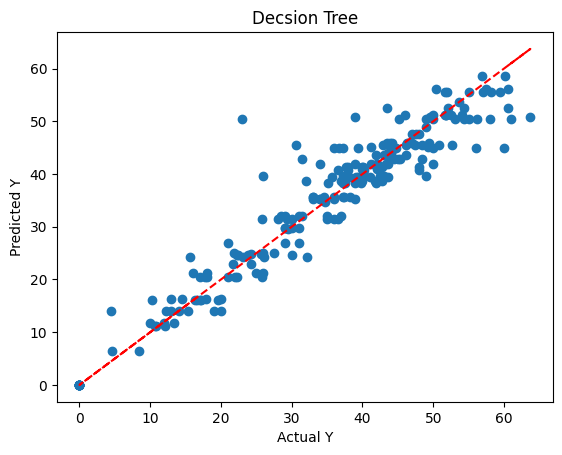

In [ ]:

print(best_para)

best_model = DecisionTreeRegressor(**best_para, random_state =42)

best_model.fit(X,y)
y_pred= best_model.predict(X)

print(best_model.get_n_leaves())
mse = mean_squared_error(y_pred,y)
mae = mean_absolute_error(y_pred,y)


r2= r2_score(y_pred,y)
print('Char Yield')
print(f'MSE: {mse}')
print(f'MAE: {mae}')
print(f'R2 score: {r2}')

plt.plot(y,y,'r--',label = 'Ideal')
plt.scatter(y,y_pred,label = 'Predicted')
plt.xlabel('Actual Y')
plt.ylabel('Predicted Y')
plt.title('Decsion Tree')
plt.show()